# Phase 2 — FADA analysis

This notebook analyses the **saved spatiotemporal FADA fits** produced by `03_Primitive_Discovery.ipynb`. It does **not fit FADA again**.

The interpretation here follows the spatiotemporal model in Chiovetto et al. (2022). In that model,

$$
x^l(t)=\sum_p c_p^l\,w_p(t-\tau_p^l)+\mathrm{residuals},
$$

where the multijoint primitive shape $w_p(t)$ is **shared across trials by model assumption**, while the coefficient $c_p^l$ and delay $\tau_p^l$ vary from trial to trial.

That distinction matters for the analysis. We are **not** testing whether the primitive shape itself is shared across subjects or conditions; the fitted model already assumes a shared library. We instead ask how the shared components are **recruited** across trials, subjects, conditions and model sizes.

The analysis therefore separates five questions:

1. **Reconstruction:** how much does each additional FADA component improve held-out reconstruction?
2. **Shape:** what multijoint temporal pattern does each learned component represent?
3. **Recruitment and timing:** which trials rely on each component, with what relative contribution and delay?
4. **Recruitment breadth:** are the shared components actually used across subjects and experimental conditions, or mainly by narrow subsets of trials?
5. **Persistence across model size:** when `K` changes, do recognizable component shapes survive, or does the decomposition reorganize completely?

Throughout the notebook, `q` denotes the phase-normalized joint trajectory and `f = q - h` denotes the endpoint-residual trajectory, where `h` is the straight interpolation between the trial's start and end configurations. The two representations are analysed separately.

No automatic "best K" is selected. Reconstruction, recruitment and persistence are inspected together. The paper itself uses an elbow in explained variance to choose the number of components for its experimental examples; our held-out NMSE is an additional generalization check rather than a reproduction of that exact procedure.


## 1. Locate the saved experiment

### Why this cell exists

The fitting notebook already defines the dataset, view, split and FADA model. An analysis notebook must point to exactly the same result directory; otherwise it is easy to combine a summary from one experiment with component files from another.

### What this cell does

It defines only **analysis settings** and filesystem locations. `INSPECT_K` controls which fitted model receives detailed visual inspection. Leaving it as `None` means "use the largest completed K" purely as a display default; that is **not** a scientific selection of K.

`EXAMPLE_TRIALS` controls how many held-out trajectories are drawn in the reconstruction section. Nothing in this notebook changes a fit on disk.


In [1]:
from pathlib import Path
import json
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import linear_sum_assignment

from motion_primitives.paths import PROJECT_ROOT
from motion_primitives.preprocessing import load_collections
from motion_primitives.fada import reconstruct, align_primitives

COLLECTION = PROJECT_ROOT / 'collections/3D-ARM-Gaze/custom-phase200-v1'
VIEW = 'successful'
SPLIT_METHOD = 'random_trial'
FADA_MODEL = 'spatiotemporal'
JOINT_NAMES = None
SEED = 42

INSPECT_K = 6
EXAMPLE_TRIALS = 3

DISCOVERY_OUTPUT = (PROJECT_ROOT / 'notebooks/results/03_Primitive_Discovery' /
                    COLLECTION.name / VIEW / SPLIT_METHOD)
FADA_OUTPUT = DISCOVERY_OUTPUT / 'fada' / FADA_MODEL
ANALYSIS_OUTPUT = (PROJECT_ROOT / 'notebooks/results/04_FADA_Analysis' /
                   COLLECTION.name / VIEW / SPLIT_METHOD / FADA_MODEL)
ANALYSIS_OUTPUT.mkdir(parents=True, exist_ok=True)


## 2. Load trajectories, metadata, split and provenance

### Why

The saved FADA files contain the learned library, coefficients and delays, but interpretation requires the original trial order and metadata. The split is also needed so that all reconstruction statements can distinguish discovery data from genuinely held-out validation/test trials.

### How

We reload the same prepared collection used during fitting and then reload the exact saved split. The trial IDs must match **in the same order**. This check is deliberate: coefficients are stored by trial index, so even a correct set of trials in a different order would attach coefficients to the wrong movements.

The `provenance.json` file supplies the FADA padding and maximum allowed delay used during fitting. The summary table tells us which values of `K` actually completed.

### What to look for

The printed output should show the expected number of trials, joints and available component counts. If the trial-order check fails, stop; the saved fits and the currently loaded collection do not correspond.


In [2]:
collection = load_collections([COLLECTION], JOINT_NAMES, view=VIEW)
Q = collection['q']
H = collection['h']
F = collection['f']
Q_START = collection['q_start']
Q_END = collection['q_end']
metadata = collection['metadata'].reset_index(drop=True)
joints = list(collection['joint_names'])

split_path = DISCOVERY_OUTPUT / f'split_{SPLIT_METHOD}.csv'
saved_split = pd.read_csv(split_path)
if saved_split.trial_id.tolist() != metadata.trial_id.tolist():
    raise ValueError('Saved split does not match the ordered trial cohort.')
split = saved_split.split.to_numpy()

provenance = json.loads((DISCOVERY_OUTPUT / 'provenance.json').read_text())
fada_summary = pd.read_csv(FADA_OUTPUT / 'summary.csv')
AVAILABLE_K = sorted(int(k) for k in fada_summary['k'].unique())
if not AVAILABLE_K:
    raise ValueError('No completed FADA fits were found.')
if INSPECT_K is None:
    INSPECT_K = AVAILABLE_K[-1]
if INSPECT_K not in AVAILABLE_K:
    raise ValueError(f'INSPECT_K={INSPECT_K} is not one of the completed fits: {AVAILABLE_K}')

FADA_PAD = int(provenance['fada']['pad'])
FADA_MAX_DELAY = int(provenance['fada']['max_delay'])
N_PHASE = Q.shape[1]
N_TIME = N_PHASE + 2 * FADA_PAD

print(f'{len(metadata)} trials, {N_PHASE} phase samples, {len(joints)} joints')
print(f'Available FADA K: {AVAILABLE_K}')
print(f'Detailed inspection K: {INSPECT_K} (display choice only)')


17007 trials, 200 phase samples, 7 joints
Available FADA K: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
Detailed inspection K: 6 (display choice only)


## 3. Helpers for reading a saved FADA fit

### Why

Every later section needs the same operations: load an `.npz`, recover the learned library, transform Fourier-domain primitives back to the time domain, and reconstruct trajectories from saved coefficients/delays. Keeping those operations in small helpers avoids duplicating scientific transformations across cells.

### How the saved representation works

For the current spatiotemporal model, a primitive is stored as a truncated Fourier representation

$$
\hat P_k(j,\omega),
$$

where `k` indexes primitives, `j` indexes joints and `ω` indexes retained Fourier frequencies. The corresponding time-domain primitive is obtained with an inverse real FFT using the same padded length used during fitting.

The padded signal has the form

$$
[0\ldots0]\;x(t)\;[0\ldots0].
$$

For plots of the movement itself we crop away the padding. For **cross-K matching** we retain the padded form because FADA explicitly permits temporal shifts.

### Important invariances

The sign and scale of a factorization are not unique: multiplying a primitive by a constant and dividing its coefficient by the same constant leaves the reconstruction unchanged. Therefore later visualization may normalize/sign-flip a copy of a primitive **for display only**. All quantitative contribution calculations compensate for primitive scale.


In [3]:
def load_fada_fit(representation, k):
    path = FADA_OUTPUT / representation / f'k{k:02d}' / 'fit.npz'
    if not path.exists():
        raise FileNotFoundError(path)
    with np.load(path) as saved:
        return {name: saved[name] for name in saved.files}


def library_from_fit(fit):
    return {name.removeprefix('library_'): value
            for name, value in fit.items() if name.startswith('library_')}


def primitive_time_domain(fit, crop=True):
    if 'library_primitive_hat' not in fit:
        raise NotImplementedError(
            'This analysis currently expects the spatiotemporal FADA model '
            '(library_primitive_hat).')
    primitive = np.fft.irfft(fit['library_primitive_hat'], n=N_TIME, axis=-1)
    if crop:
        primitive = primitive[..., FADA_PAD:FADA_PAD + N_PHASE]
    return primitive  # [primitive, joint, time]


def canonicalize_for_display(primitive):
    # Unit-normalize and choose a deterministic sign for plots only.
    p = np.array(primitive, dtype=float, copy=True)
    flat = p.reshape(len(p), -1)
    norms = np.linalg.norm(flat, axis=1)
    norms[norms == 0] = 1.0
    p /= norms[:, None, None]
    flat = p.reshape(len(p), -1)
    peak = np.argmax(np.abs(flat), axis=1)
    signs = np.sign(flat[np.arange(len(p)), peak])
    signs[signs == 0] = 1.0
    return p * signs[:, None, None]


def reconstruct_from_fit(fit, coefficients=None):
    """Reconstruct all trials from a saved fit, optionally replacing its coefficients."""
    library = library_from_fit(fit)
    n_freq = next(iter(library.values())).shape[-1]
    omega = 2 * np.pi * np.arange(n_freq) / N_TIME
    if coefficients is None:
        coefficients = fit['coefficients']
    fitted_hat = reconstruct(library, coefficients, fit['delays'], omega)
    fitted = np.fft.irfft(fitted_hat, n=N_TIME, axis=-1)
    fitted = fitted[..., FADA_PAD:FADA_PAD + N_PHASE].transpose(0, 2, 1)
    return fitted + fit['mean'][None, None, :]


def reconstruct_saved_fit(representation, k):
    return reconstruct_from_fit(load_fada_fit(representation, k))


def nmse(actual, predicted):
    actual = np.asarray(actual)
    predicted = np.asarray(predicted)
    center_axes = tuple(range(actual.ndim - 1))
    mean = actual.mean(axis=center_axes, keepdims=True)
    denom = np.sum((actual - mean) ** 2)
    return np.sum((actual - predicted) ** 2) / denom


## 4. Held-out reconstruction and the elbow in K

### Why

We need to know whether adding more FADA components keeps buying substantial reconstruction, or whether the curve has reached a point where extra components only make small improvements.

Chiovetto et al. use an **elbow method** on the explained-variance ($R^2$) curve for their experimental examples. Their rule is: choose the **smallest number of primitives from which the remaining $R^2$ curve can be fitted well by a straight line**, with mean squared fitting error below $10^{-4}$.

We apply the same rule here to our **held-out test-set explained variance**. This is therefore a paper-style elbow criterion applied to our held-out evaluation, rather than a literal reproduction of their experimental-data protocol.

### What this cell computes

For `q` and `f` separately it shows:

1. **Test NMSE** as K increases. Lower is better.
2. **Gain from adding one more component**. This shows when another component stops helping much.
3. **Explained variance ($R^2$)** and the automatically detected elbow using the paper's $10^{-4}$ straight-line criterion.

### Interpretation

- The elbow is a practical trade-off between reconstruction quality and model size.
- It is a way to choose a compact K; it does **not** establish that K is the true biological number of primitives.
- `q` and `f` should be considered separately because they are different representations of the same movements.


,representation,k,nmse,variance_explained,nmse_gain_from_previous_k
35,f,2,0.397030,0.602970,NaN
38,f,3,0.301668,0.698332,0.095363
41,f,4,0.209233,0.790767,0.092434
44,f,5,0.163585,0.836415,0.045648
47,f,6,0.128229,0.871771,0.035357
50,f,7,0.099105,0.900895,0.029124
53,f,8,0.076906,0.923094,0.022198
56,f,9,0.056872,0.943128,0.020034
59,f,10,0.046713,0.953287,0.010159
62,f,11,0.038972,0.961028,0.007741


,representation,candidate_k,tail_line_mse,passes_threshold
0,q,2,1.255491e-03,False
1,q,3,6.897618e-04,False
2,q,4,4.873906e-04,False
3,q,5,3.469906e-04,False
4,q,6,2.138104e-04,False
5,q,7,8.525307e-05,True
6,q,8,1.312080e-05,True
7,q,9,2.407455e-06,True
8,q,10,2.525750e-06,True
9,f,2,1.928506e-03,False


Paper-style elbow K: {'q': 7, 'f': 6}


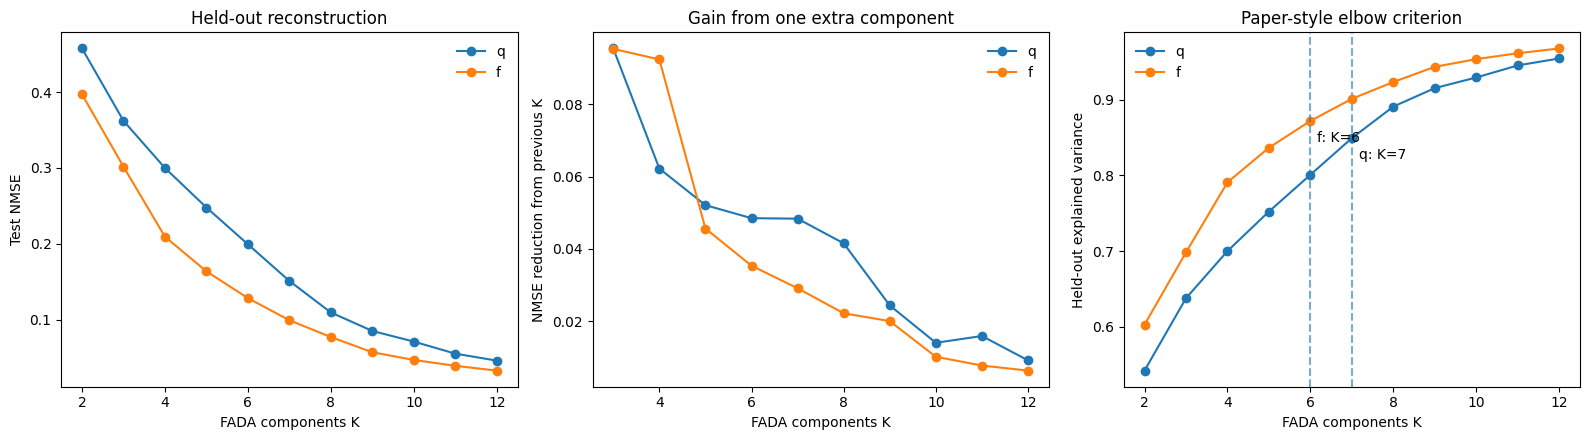

Detailed F-component analysis will use K=6.


In [4]:
test_rows = fada_summary[fada_summary['split'] == 'test'].copy()
test_rows = test_rows.sort_values(['representation', 'k'])
test_rows['nmse_gain_from_previous_k'] = (
    test_rows.groupby('representation')['nmse'].shift(1) - test_rows['nmse'])

display(test_rows[['representation', 'k', 'nmse', 'variance_explained',
                   'nmse_gain_from_previous_k']])

# Paper-style elbow criterion from Chiovetto et al. (2022):
# choose the smallest K from which a straight line fits the remaining R^2 curve
# with mean squared error below 1e-4.
ELBOW_MSE_THRESHOLD = 1e-4

def paper_style_elbow(rows, threshold=ELBOW_MSE_THRESHOLD):
    rows = rows.sort_values('k')
    ks = rows['k'].to_numpy(dtype=float)
    r2 = rows['variance_explained'].to_numpy(dtype=float)

    diagnostics = []
    elbow = None

    # Require at least 3 points in the remaining tail so that the line-fit test
    # is not trivially perfect because only two points remain.
    for start in range(max(0, len(ks) - 2)):
        tail_k = ks[start:]
        tail_r2 = r2[start:]
        slope, intercept = np.polyfit(tail_k, tail_r2, 1)
        fitted = slope * tail_k + intercept
        mse = float(np.mean((tail_r2 - fitted) ** 2))
        diagnostics.append({
            'candidate_k': int(ks[start]),
            'tail_line_mse': mse,
            'passes_threshold': mse < threshold,
        })
        if elbow is None and mse < threshold:
            elbow = int(ks[start])

    return elbow, pd.DataFrame(diagnostics)

elbows = {}
elbow_tables = []
for representation in ('q', 'f'):
    rows = test_rows[test_rows.representation == representation]
    elbow, diagnostics = paper_style_elbow(rows)
    elbows[representation] = elbow
    diagnostics.insert(0, 'representation', representation)
    elbow_tables.append(diagnostics)

elbow_diagnostics = pd.concat(elbow_tables, ignore_index=True)
display(elbow_diagnostics)
print('Paper-style elbow K:', elbows)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for representation in ('q', 'f'):
    rows = test_rows[test_rows.representation == representation]
    axes[0].plot(rows.k, rows.nmse, marker='o', label=representation)
    axes[1].plot(rows.k, rows.nmse_gain_from_previous_k, marker='o', label=representation)
    axes[2].plot(rows.k, rows.variance_explained, marker='o', label=representation)

    elbow = elbows[representation]
    if elbow is not None:
        axes[2].axvline(elbow, linestyle='--', alpha=0.6)
        elbow_r2 = float(rows.loc[rows.k == elbow, 'variance_explained'].iloc[0])
        axes[2].annotate(
            f'{representation}: K={elbow}',
            xy=(elbow, elbow_r2),
            xytext=(5, -15),
            textcoords='offset points',
        )

axes[0].set(xlabel='FADA components K', ylabel='Test NMSE',
            title='Held-out reconstruction')
axes[1].set(xlabel='FADA components K', ylabel='NMSE reduction from previous K',
            title='Gain from one extra component')
axes[2].set(xlabel='FADA components K', ylabel='Held-out explained variance',
            title='Paper-style elbow criterion')
for ax in axes:
    ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(ANALYSIS_OUTPUT / 'reconstruction_and_elbow_vs_k.png', bbox_inches='tight')
plt.show()

# The deeper FADA analyses below focus on the residual representation F.
# Use its paper-style elbow automatically; fall back to INSPECT_K only if no elbow was found.
F_ANALYSIS_K = elbows.get('f') if elbows.get('f') is not None else INSPECT_K
print(f'Detailed F-component analysis will use K={F_ANALYSIS_K}.')


## 5. Visualize the learned spatiotemporal primitives

### Why

A FADA component is not just a scalar direction in joint space. In the spatiotemporal model it is a **multijoint trajectory-shaped motif**. Looking at these shapes is therefore necessary before assigning any motor interpretation.

### How

For the chosen `INSPECT_K`, each Fourier-domain primitive is transformed back to time. Each panel shows a matrix with:

- rows = joints;
- columns = movement phase;
- value = signed primitive displacement.

For visualization only, each primitive is unit-normalized and its sign is chosen deterministically so that the largest-magnitude element is positive. This prevents arbitrary factor scale/sign from dominating the plot.

### What to look for

Look for coordinated structure rather than isolated noise:

- Does a primitive recruit several joints in a coherent temporal sequence?
- Is its activity localized to an early/middle/late part of the movement?
- Do `q` and `f` primitives differ primarily by endpoint/postural structure?
- Are several primitives nearly duplicates of one another?

Do **not** interpret the displayed sign as biologically meaningful; the sign can be exchanged with the coefficient sign.


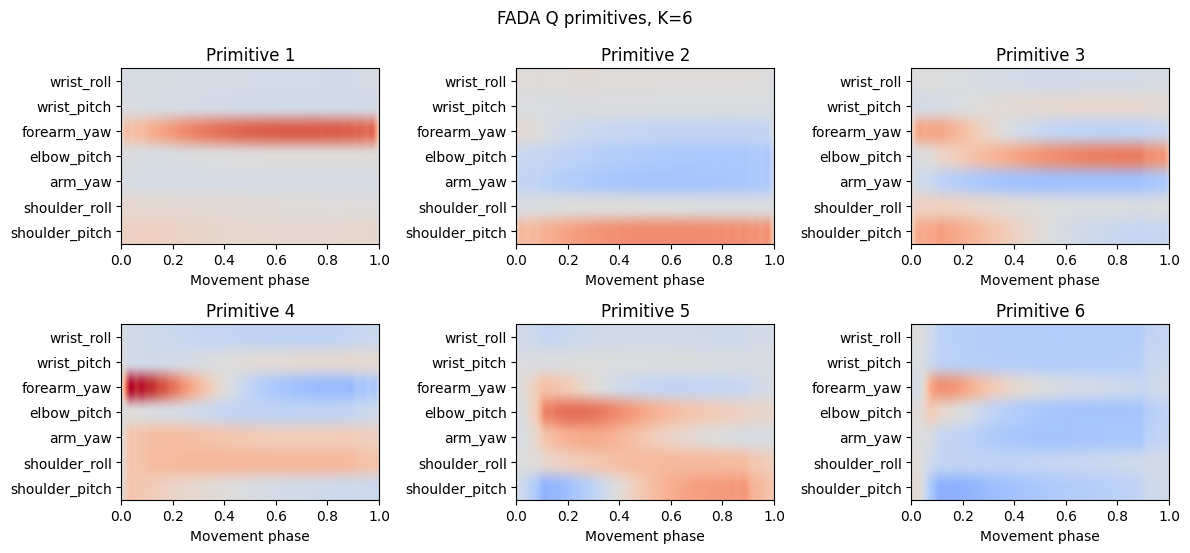

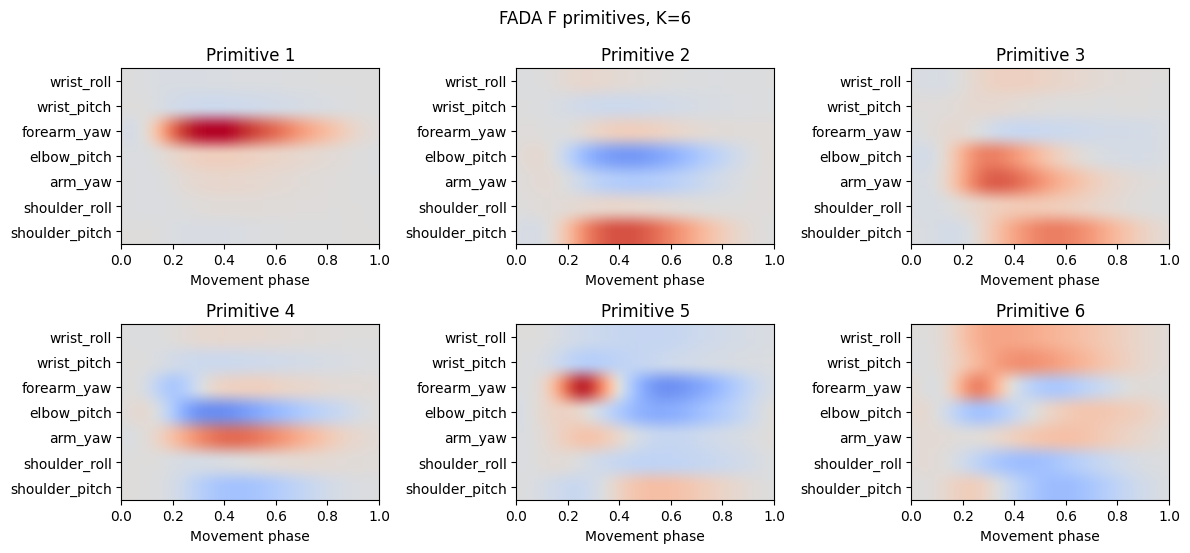

In [5]:
for representation in ('q', 'f'):
    fit = load_fada_fit(representation, INSPECT_K)
    primitive = canonicalize_for_display(primitive_time_domain(fit, crop=True))

    ncols = 3
    nrows = math.ceil(len(primitive) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(12, 2.8 * nrows), squeeze=False)
    vmax = np.max(np.abs(primitive))
    for i, ax in enumerate(axes.flat):
        if i >= len(primitive):
            ax.axis('off')
            continue
        image = ax.imshow(primitive[i], aspect='auto', origin='lower',
                          extent=[0, 1, 0, len(joints)], vmin=-vmax, vmax=vmax,
                          cmap='coolwarm')
        ax.set_title(f'Primitive {i + 1}')
        ax.set_xlabel('Movement phase')
        ax.set_yticks(np.arange(len(joints)) + 0.5)
        ax.set_yticklabels(joints)
    fig.suptitle(f'FADA {representation.upper()} primitives, K={INSPECT_K}')
    fig.tight_layout()
    fig.savefig(ANALYSIS_OUTPUT / f'{representation}_k{INSPECT_K:02d}_primitive_heatmaps.png',
                bbox_inches='tight')
    plt.show()


## 6. Quantify trial-wise component recruitment

### Why raw coefficients are not enough

In the spatiotemporal FADA model, the trial-specific coefficient $c_{ak}$ tells us how strongly trial `a` uses component `k`. However, the factorization has a scale ambiguity. If

$$
P_k \rightarrow aP_k, \qquad c_{ak} \rightarrow c_{ak}/a,
$$

the reconstructed trajectory is unchanged. Comparing `|c|` across components can therefore be misleading when component norms differ.

### How

For trial `a` and component `k` we define a scale-aware contribution magnitude

$$
A_{ak}=|c_{ak}|\,\|P_k\|_2.
$$

We then normalize within each trial,

$$
p_{ak}=\frac{A_{ak}}{\sum_j A_{aj}},
$$

so the `p` values describe the **relative share of the fitted reconstruction contributed by each component** for that trial.

We also compute the participation ratio

$$
N_{\mathrm{eff}}(a)=\frac{1}{\sum_k p_{ak}^2}.
$$

Here `1` means one component dominates the fitted contribution, while values approaching `K` mean the contribution is spread broadly across components.

### Important terminology

`N_eff` is **our summary statistic**, not a quantity defined by FADA or by Chiovetto et al. It should be read as an **effective number of component contributions**, not as "the number of motor primitives contained in the movement."

### What this tells us

This analysis asks how concentrated or distributed the fitted component contributions are. A distributed mixture is perfectly compatible with the FADA model; it simply means that the trial is reconstructed through several shared components rather than one dominant component.


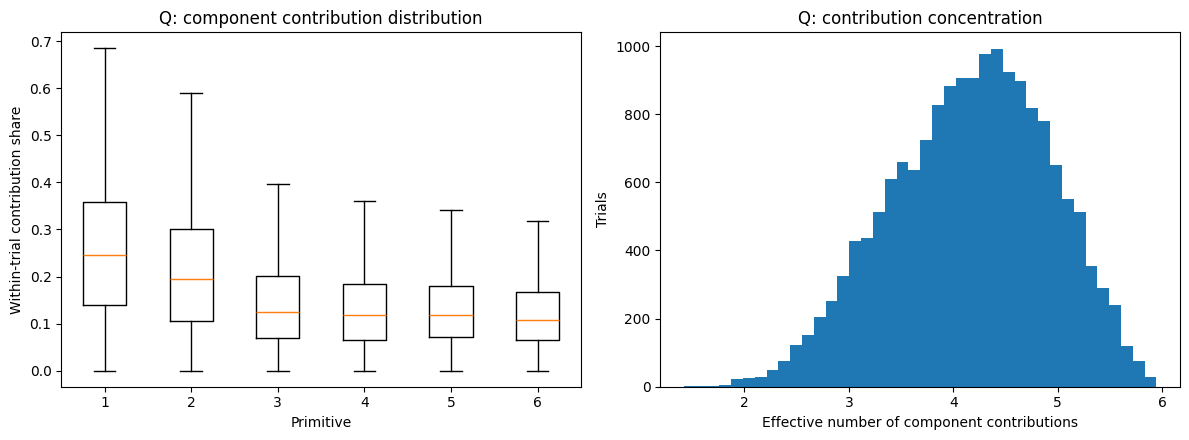

Q median effective component contributions = 4.20796012878418 of 6


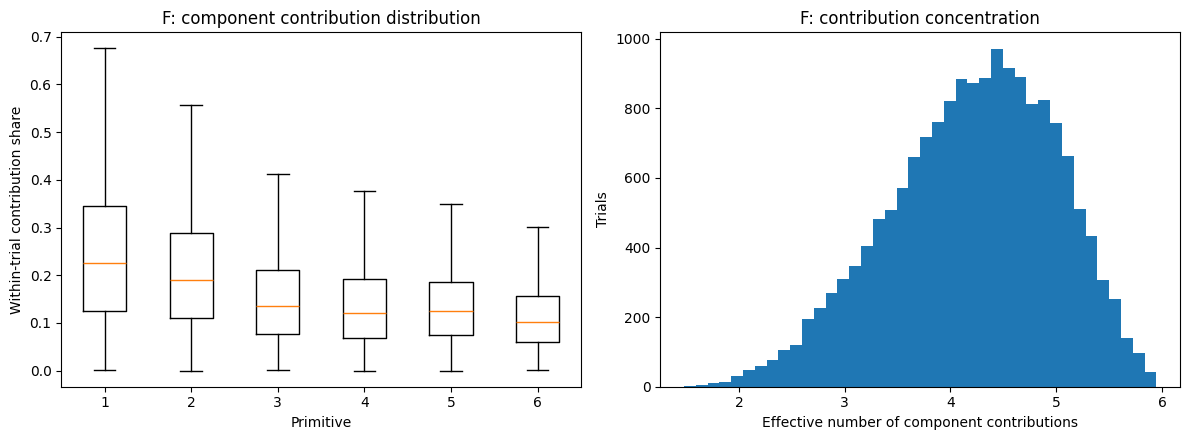

F median effective component contributions = 4.271528828194414 of 6


In [6]:
def recruitment_for_fit(representation, k):
    fit = load_fada_fit(representation, k)
    coefficients = np.asarray(fit['coefficients'])
    if coefficients.ndim != 2:
        raise NotImplementedError('Recruitment analysis currently expects spatiotemporal coefficients [trial, K].')
    primitive = primitive_time_domain(fit, crop=False)
    primitive_norm = np.linalg.norm(primitive.reshape(k, -1), axis=1)
    contribution = np.abs(coefficients) * primitive_norm[None, :]
    total = contribution.sum(axis=1, keepdims=True)
    shares = np.divide(contribution, total, out=np.zeros_like(contribution), where=total != 0)
    effective_n = 1.0 / np.sum(shares ** 2, axis=1)
    return contribution, shares, effective_n

for representation in ('q', 'f'):
    contribution, shares, effective_n = recruitment_for_fit(representation, INSPECT_K)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    axes[0].boxplot([shares[:, i] for i in range(INSPECT_K)], showfliers=False)
    axes[0].set(xlabel='Primitive', ylabel='Within-trial contribution share',
                title=f'{representation.upper()}: component contribution distribution')
    axes[1].hist(effective_n, bins=40)
    axes[1].set(xlabel='Effective number of component contributions', ylabel='Trials',
                title=f'{representation.upper()}: contribution concentration')
    fig.tight_layout()
    fig.savefig(ANALYSIS_OUTPUT / f'{representation}_k{INSPECT_K:02d}_recruitment.png',
                bbox_inches='tight')
    plt.show()

    print(representation.upper(),
          'median effective component contributions =', float(np.median(effective_n)),
          'of', INSPECT_K)


## 7. Is each FADA component recruited across many start/end contexts?

### Why

The spatiotemporal FADA model already assumes that the component shape $w_p(t)$ is shared across trials. Therefore, seeing the same component in many trials is **not by itself evidence of generalization**.

What we can test from the data is different:

> When a component contributes strongly, do those trials cover many different starting and ending postures, or is that component mainly used in one narrow part of the task?

That matters for the later SOC idea. A component is more useful as a candidate reusable movement pattern if its recruitment is not tied to one specific endpoint context.

### How

For the residual representation `F`, at the paper-style elbow $K$, we use the already-computed scale-aware contribution magnitude $A_{ap}=|c_{ap}|\,\|P_p\|$. For a given component, this is proportional to the magnitude of its trial-specific FADA coefficient, while avoiding confusion from component scaling. We restrict this analysis to **held-out test trials**.

For each component we weight every test trial by that component's contribution magnitude and measure the spread of:

- `q_start` in the 7-dimensional joint space;
- `q_end` in the 7-dimensional joint space.

The spread is the weighted RMS distance from the weighted centre. We then divide it by the ordinary spread of **all test trials**. Therefore:

- ratio near `1` → the component is recruited over endpoint contexts about as broad as the whole test set;
- ratio below `1` → its recruitment is concentrated in a narrower region;
- ratio above `1` → its strongest recruitment is unusually dispersed.

We also report an **effective number of test trials** contributing to each component. This prevents a broad-looking spread produced by only a handful of highly weighted trials from being mistaken for broad recruitment.

This context-breadth measure is **our post-analysis**, not a quantity defined by Chiovetto et al. The FADA quantities we use—the trial-specific component coefficients—are part of the spatiotemporal model.


,primitive,start_spread,end_spread,start_spread_ratio_to_all_test,end_spread_ratio_to_all_test,effective_weighted_test_trials,mean_test_scale_aware_contribution
0,1,1.226192,1.244728,1.051626,1.049083,1882.998511,3.333131
1,2,1.211339,1.238206,1.038887,1.043586,1932.230997,2.800029
2,3,1.187434,1.218139,1.018385,1.026673,2064.966300,1.860065
3,4,1.236549,1.251283,1.060508,1.054608,2013.969237,1.732000
4,5,1.196822,1.252555,1.026438,1.055680,2111.423730,1.685353
5,6,1.180200,1.227303,1.012182,1.034397,2035.940003,1.407674


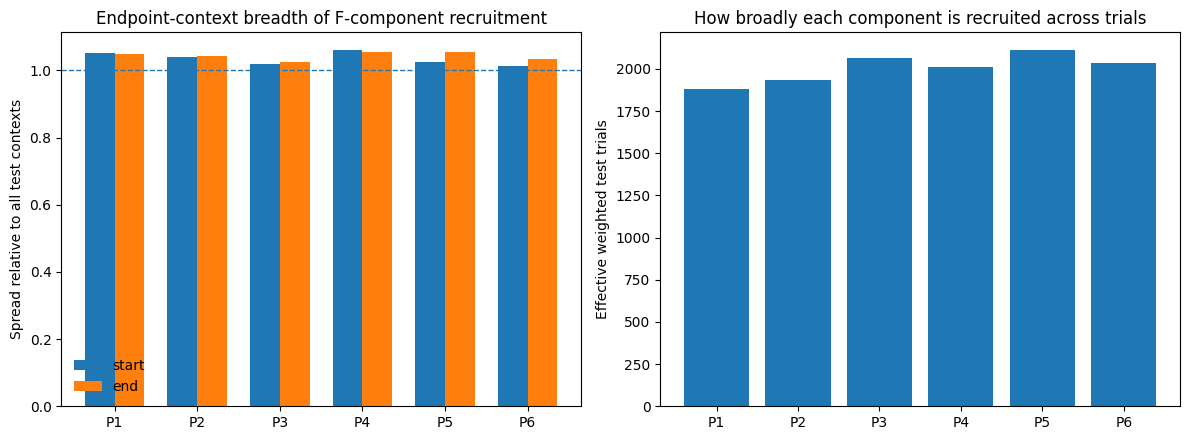

In [7]:
def weighted_rms_spread(points, weights):
    points = np.asarray(points, dtype=float)
    weights = np.asarray(weights, dtype=float)
    total = weights.sum()
    if total <= 0:
        return np.nan
    w = weights / total
    centre = np.sum(points * w[:, None], axis=0)
    squared_distance = np.sum((points - centre) ** 2, axis=1)
    return float(np.sqrt(np.sum(w * squared_distance)))


def effective_weighted_trials(weights):
    weights = np.asarray(weights, dtype=float)
    total = weights.sum()
    if total <= 0:
        return 0.0
    w = weights / total
    return float(1.0 / np.sum(w ** 2))


f_contribution, _, _ = recruitment_for_fit('f', F_ANALYSIS_K)
test_mask = split == 'test'
start_test = Q_START[test_mask]
end_test = Q_END[test_mask]
f_test_contribution = f_contribution[test_mask]

# Uniform-weight spread of the entire held-out test cohort: our reference breadth.
uniform = np.ones(test_mask.sum(), dtype=float)
all_start_spread = weighted_rms_spread(start_test, uniform)
all_end_spread = weighted_rms_spread(end_test, uniform)

context_rows = []
for p in range(F_ANALYSIS_K):
    weights = f_test_contribution[:, p]
    start_spread = weighted_rms_spread(start_test, weights)
    end_spread = weighted_rms_spread(end_test, weights)
    context_rows.append({
        'primitive': p + 1,
        'start_spread': start_spread,
        'end_spread': end_spread,
        'start_spread_ratio_to_all_test': start_spread / all_start_spread,
        'end_spread_ratio_to_all_test': end_spread / all_end_spread,
        'effective_weighted_test_trials': effective_weighted_trials(weights),
        'mean_test_scale_aware_contribution': float(np.mean(weights)),
    })

context_breadth = pd.DataFrame(context_rows)
display(context_breadth)
context_breadth.to_csv(
    ANALYSIS_OUTPUT / f'f_k{F_ANALYSIS_K:02d}_context_breadth.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
x = np.arange(F_ANALYSIS_K)
width = 0.36
axes[0].bar(x - width / 2,
            context_breadth['start_spread_ratio_to_all_test'],
            width=width, label='start')
axes[0].bar(x + width / 2,
            context_breadth['end_spread_ratio_to_all_test'],
            width=width, label='end')
axes[0].axhline(1.0, linestyle='--', linewidth=1)
axes[0].set_xticks(x)
axes[0].set_xticklabels([f'P{i + 1}' for i in x])
axes[0].set(ylabel='Spread relative to all test contexts',
            title='Endpoint-context breadth of F-component recruitment')
axes[0].legend(frameon=False)

axes[1].bar(x, context_breadth['effective_weighted_test_trials'])
axes[1].set_xticks(x)
axes[1].set_xticklabels([f'P{i + 1}' for i in x])
axes[1].set(ylabel='Effective weighted test trials',
            title='How broadly each component is recruited across trials')
fig.tight_layout()
fig.savefig(ANALYSIS_OUTPUT / f'f_k{F_ANALYSIS_K:02d}_context_breadth.png',
            bbox_inches='tight')
plt.show()


## 8. How much does the fitted model rely on each FADA component?

### Why

A component can receive a noticeable coefficient without being essential for reconstruction. Conversely, removing one component may substantially damage the fit.

Because the spatiotemporal FADA reconstruction is additive,

$$
\hat F^l(t)=\sum_p c_p^l\,w_p(t-\tau_p^l),
$$

we can remove component $p$ from the **already fitted model** by setting its trial coefficients to zero and reconstructing again. No FADA refitting is performed.

### What we measure

For each component, on held-out test trials:

1. reconstruct with all components;
2. set that component's coefficients to zero;
3. reconstruct again;
4. record how much the error increases.

We report this both in residual space `F` and after returning to the original joint trajectory:

$$
\hat Q = H + \hat F.
$$

A larger increase means the fitted model relies more strongly on that component.

### Interpretation limit

This is **not** a biological importance score and it is not a metric introduced by the FADA paper. Components may overlap, so one component can be meaningful even if another component partly compensates for it. This analysis only asks how important that component is **inside this fitted decomposition**.


,primitive,full_f_test_nmse,f_test_nmse_without_component,delta_f_test_nmse,full_q_test_nmse_from_h_plus_f,q_test_nmse_without_component,delta_q_test_nmse
0,1,0.128229,0.507865,0.379636,0.027479,0.108834,0.081355
1,2,0.128229,0.389370,0.261142,0.027479,0.083441,0.055962
2,3,0.128229,0.236139,0.107910,0.027479,0.050604,0.023125
3,4,0.128229,0.224117,0.095889,0.027479,0.048028,0.020549
4,5,0.128229,0.214936,0.086707,0.027479,0.046060,0.018581
5,6,0.128229,0.190911,0.062683,0.027479,0.040912,0.013433


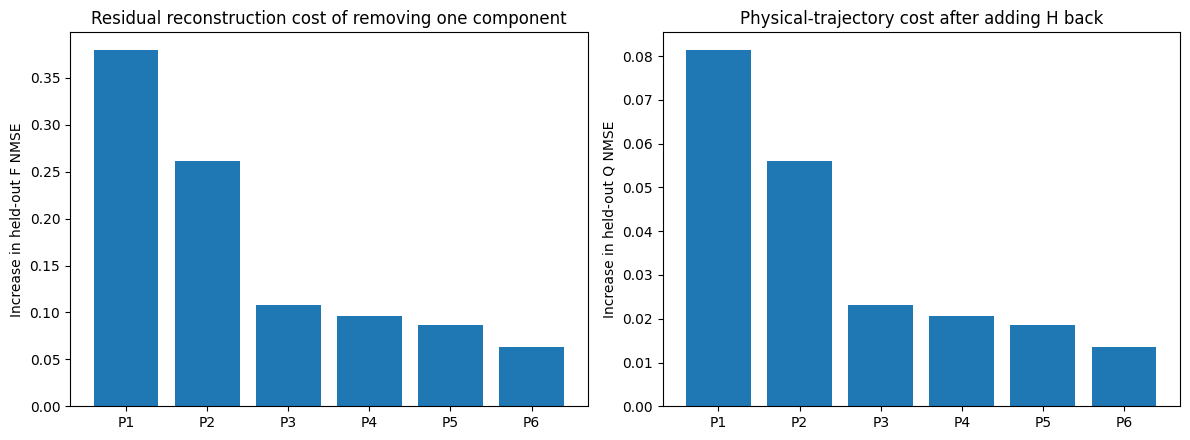

Full F test NMSE at K=6: 0.128229
Full H + FADA(F) test NMSE at K=6: 0.027479


,primitive,start_spread,end_spread,start_spread_ratio_to_all_test,end_spread_ratio_to_all_test,effective_weighted_test_trials,mean_test_scale_aware_contribution,delta_f_test_nmse,delta_q_test_nmse
0,1,1.226192,1.244728,1.051626,1.049083,1882.998511,3.333131,0.379636,0.081355
1,2,1.211339,1.238206,1.038887,1.043586,1932.230997,2.800029,0.261142,0.055962
2,3,1.187434,1.218139,1.018385,1.026673,2064.966300,1.860065,0.107910,0.023125
3,4,1.236549,1.251283,1.060508,1.054608,2013.969237,1.732000,0.095889,0.020549
4,5,1.196822,1.252555,1.026438,1.055680,2111.423730,1.685353,0.086707,0.018581
5,6,1.180200,1.227303,1.012182,1.034397,2035.940003,1.407674,0.062683,0.013433


In [8]:
f_fit = load_fada_fit('f', F_ANALYSIS_K)
full_f_reconstruction = reconstruct_from_fit(f_fit)
full_f_test_nmse = nmse(F[test_mask], full_f_reconstruction[test_mask])
full_q_from_f = H + full_f_reconstruction
full_q_test_nmse = nmse(Q[test_mask], full_q_from_f[test_mask])

ablation_rows = []
for p in range(F_ANALYSIS_K):
    coefficients_without_p = np.array(f_fit['coefficients'], copy=True)
    coefficients_without_p[:, p] = 0.0

    f_without_p = reconstruct_from_fit(f_fit, coefficients=coefficients_without_p)
    q_without_p = H + f_without_p

    f_nmse_without = nmse(F[test_mask], f_without_p[test_mask])
    q_nmse_without = nmse(Q[test_mask], q_without_p[test_mask])

    ablation_rows.append({
        'primitive': p + 1,
        'full_f_test_nmse': full_f_test_nmse,
        'f_test_nmse_without_component': f_nmse_without,
        'delta_f_test_nmse': f_nmse_without - full_f_test_nmse,
        'full_q_test_nmse_from_h_plus_f': full_q_test_nmse,
        'q_test_nmse_without_component': q_nmse_without,
        'delta_q_test_nmse': q_nmse_without - full_q_test_nmse,
    })

component_ablation = pd.DataFrame(ablation_rows)
display(component_ablation)
component_ablation.to_csv(
    ANALYSIS_OUTPUT / f'f_k{F_ANALYSIS_K:02d}_component_ablation.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
x = np.arange(F_ANALYSIS_K)
axes[0].bar(x, component_ablation['delta_f_test_nmse'])
axes[0].set_xticks(x)
axes[0].set_xticklabels([f'P{i + 1}' for i in x])
axes[0].set(ylabel='Increase in held-out F NMSE',
            title='Residual reconstruction cost of removing one component')

axes[1].bar(x, component_ablation['delta_q_test_nmse'])
axes[1].set_xticks(x)
axes[1].set_xticklabels([f'P{i + 1}' for i in x])
axes[1].set(ylabel='Increase in held-out Q NMSE',
            title='Physical-trajectory cost after adding H back')
fig.tight_layout()
fig.savefig(ANALYSIS_OUTPUT / f'f_k{F_ANALYSIS_K:02d}_component_ablation.png',
            bbox_inches='tight')
plt.show()

print(f'Full F test NMSE at K={F_ANALYSIS_K}: {full_f_test_nmse:.6f}')
print(f'Full H + FADA(F) test NMSE at K={F_ANALYSIS_K}: {full_q_test_nmse:.6f}')

# Put the two component-level questions side by side: how broadly is each
# component recruited, and how much does the fitted reconstruction rely on it?
component_summary = context_breadth.merge(
    component_ablation[['primitive', 'delta_f_test_nmse', 'delta_q_test_nmse']],
    on='primitive', how='left')
component_summary.to_csv(
    ANALYSIS_OUTPUT / f'f_k{F_ANALYSIS_K:02d}_component_summary.csv', index=False)
display(component_summary)


## 9. Analyse FADA delays

### Why

One reason to use FADA instead of a static factorization is that the same primitive can be shifted in time from one trial to another. If a motif is genuinely reused, variation in **when** it is expressed may be meaningful rather than requiring a separate component for every timing.

### How

The saved `delays` are in samples of the phase-normalized trajectory. Because every movement has `N_PHASE` phase samples, we divide by `N_PHASE` to express delay as a fraction of the movement duration:

$$
\tau^{(\phi)}_{ak}=\tau_{ak}/N_{phase}.
$$

For example, with 200 phase samples, a delay of `20` corresponds to `0.10` of the normalized movement duration.

### What to look for

- A component with a narrow delay distribution may occur at a stereotyped phase of movement.
- A broad delay distribution may indicate genuine temporal reuse.
- Delays piled up at the allowed bounds (`±max_delay`) may indicate that the model would prefer shifts outside the permitted range; that is a fitting constraint worth noticing.
- Delay should be interpreted together with recruitment. A delay attached to a negligibly weighted component is not very informative.


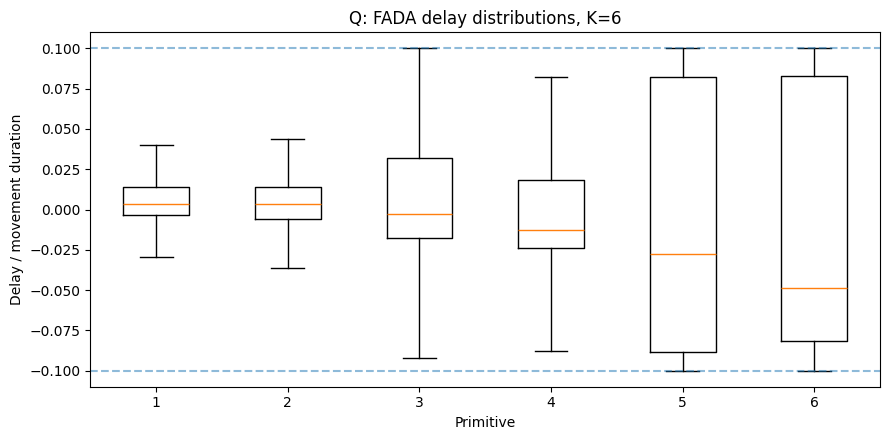

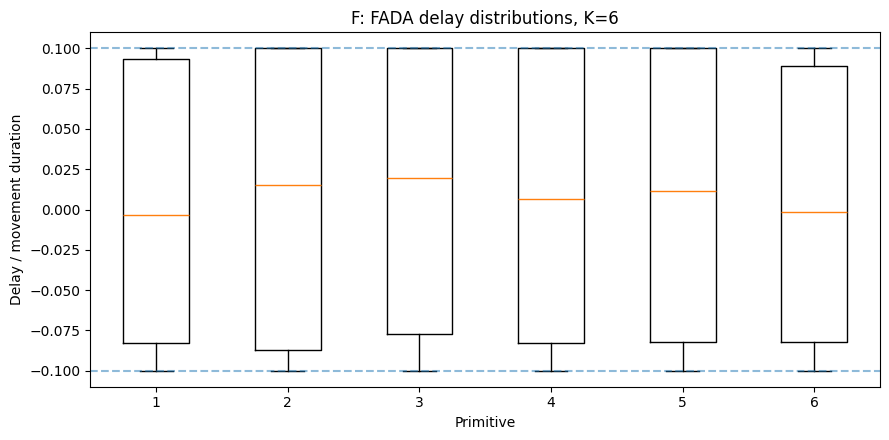

In [9]:
for representation in ('q', 'f'):
    fit = load_fada_fit(representation, INSPECT_K)
    delays = np.asarray(fit['delays'])
    if delays.ndim != 2:
        raise NotImplementedError('Delay analysis currently expects [trial, K] delays.')
    delay_phase = delays / N_PHASE

    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.boxplot([delay_phase[:, i] for i in range(INSPECT_K)], showfliers=False)
    ax.axhline(FADA_MAX_DELAY / N_PHASE, linestyle='--', alpha=0.5)
    ax.axhline(-FADA_MAX_DELAY / N_PHASE, linestyle='--', alpha=0.5)
    ax.set(xlabel='Primitive', ylabel='Delay / movement duration',
           title=f'{representation.upper()}: FADA delay distributions, K={INSPECT_K}')
    fig.tight_layout()
    fig.savefig(ANALYSIS_OUTPUT / f'{representation}_k{INSPECT_K:02d}_delays.png',
                bbox_inches='tight')
    plt.show()


## 10. Recruitment across subjects and experimental conditions

### Why

In the spatiotemporal FADA model, the primitive shapes are **shared across all trials by construction**. Therefore this section must not be interpreted as proving that "the same primitive exists in different subjects"; the model already imposes a common library.

The empirical question is narrower and useful:

> **Which subjects and conditions actually recruit each shared component, and in what proportions?**

A component that receives substantial contribution across many subjects and conditions is being used broadly by the fitted model. A component whose contribution is concentrated in only one narrow subset of trials is more context-specific within this decomposition.

### How

For each trial we use the scale-corrected contribution shares from the previous section. We then average those shares within available metadata groups such as:

- `subject`;
- `condition`;
- `action`.

The heatmap value is therefore the **mean fraction of fitted component contribution** in that group, not the raw coefficient.

### Interpretation

Differences between subjects or conditions are descriptive and may reflect genuine behavioral differences. The useful question is the **breadth of recruitment** of each shared component.

Start/end-context recruitment is a separate analysis because it requires a defensible definition of context. We should not create arbitrary target bins just to force a categorical comparison.


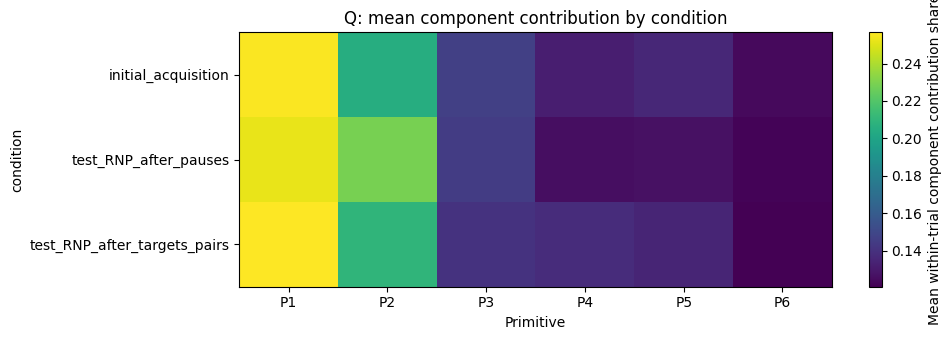

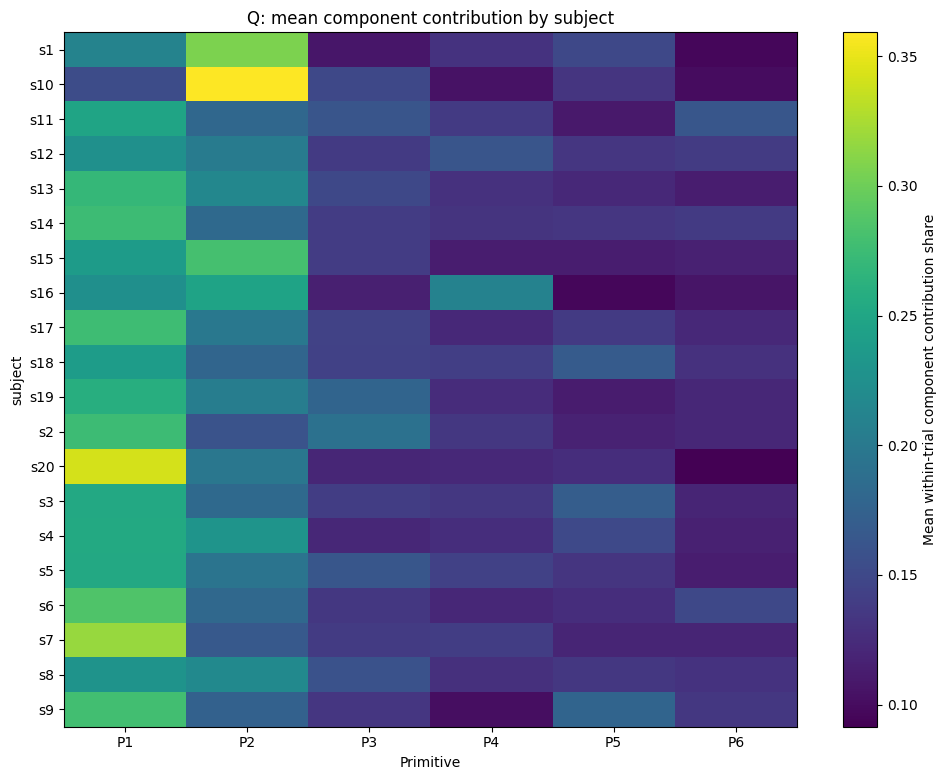

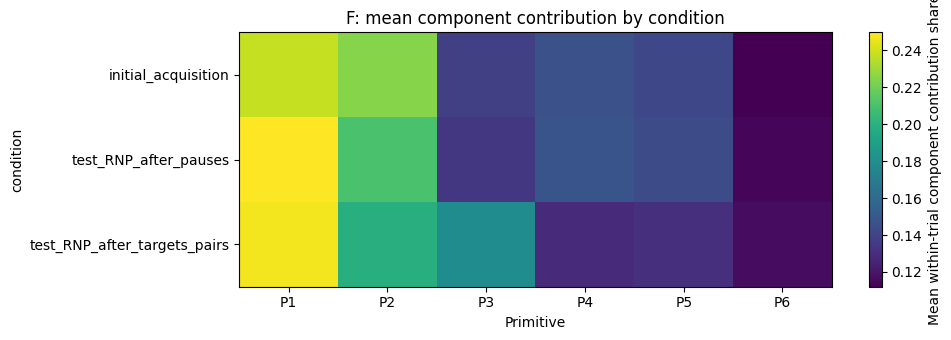

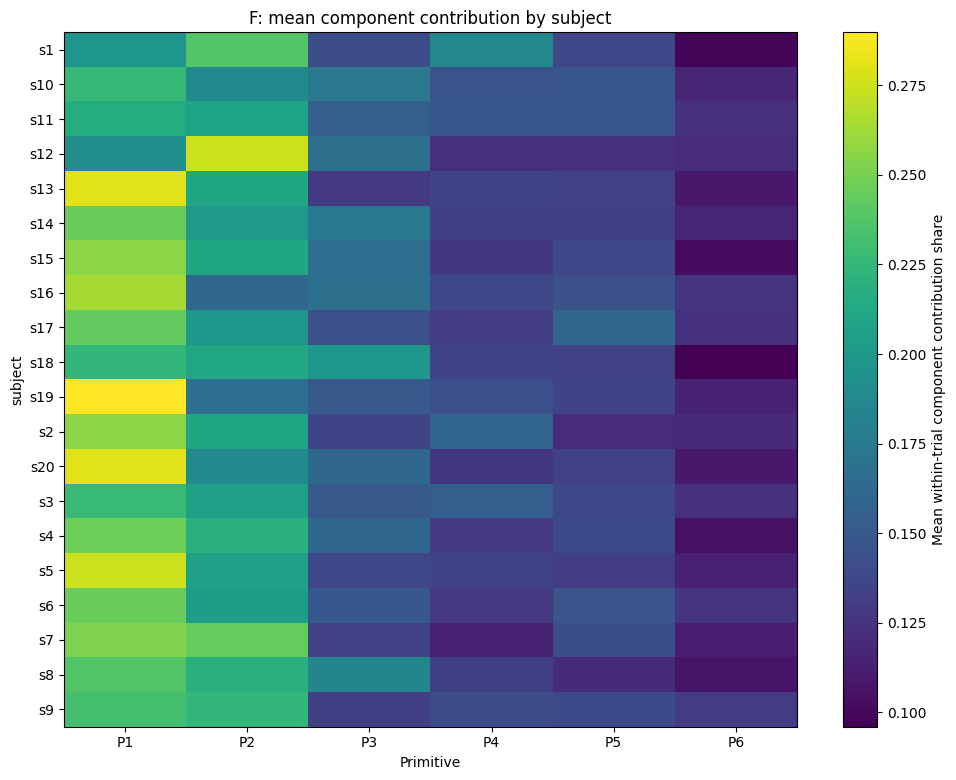

In [10]:
def plot_group_reuse(representation, k, group_col):
    if group_col not in metadata.columns:
        return
    _, shares, _ = recruitment_for_fit(representation, k)
    frame = metadata[[group_col]].copy()
    for i in range(k):
        frame[f'P{i + 1}'] = shares[:, i]
    grouped = frame.groupby(group_col, dropna=False).mean(numeric_only=True)
    if len(grouped) < 2:
        return

    fig_height = max(3.5, 0.32 * len(grouped) + 1.5)
    fig, ax = plt.subplots(figsize=(10, fig_height))
    image = ax.imshow(grouped.to_numpy(), aspect='auto')
    ax.set_xticks(range(k))
    ax.set_xticklabels([f'P{i + 1}' for i in range(k)])
    ax.set_yticks(range(len(grouped)))
    ax.set_yticklabels([str(x) for x in grouped.index])
    ax.set(xlabel='Primitive', ylabel=group_col,
           title=f'{representation.upper()}: mean component contribution by {group_col}')
    fig.colorbar(image, ax=ax, label='Mean within-trial component contribution share')
    fig.tight_layout()
    fig.savefig(ANALYSIS_OUTPUT /
                f'{representation}_k{k:02d}_reuse_by_{group_col}.png', bbox_inches='tight')
    plt.show()

for representation in ('q', 'f'):
    for group_col in ('condition', 'subject', 'action'):
        plot_group_reuse(representation, INSPECT_K, group_col)


## 11. Cross-K persistence: do component shapes survive as the library grows?

### Why

Component labels are arbitrary. "Primitive 1" at `K=5` has no guaranteed relationship to "Primitive 1" at `K=6`, so components cannot be compared by index.

We therefore ask a simple robustness question: when model capacity changes, do similar component shapes remain present?

### How: correlation + Hungarian assignment

For every adjacent pair of completed fits, we compute the absolute correlation between every component at `K` and every component at `K+1`, allowing temporal shifts up to the FADA delay limit. This produces a rectangular similarity matrix.

The **Hungarian assignment algorithm** then finds the one-to-one pairing that maximizes total similarity. This is only a bookkeeping step: it prevents several components at one K from all being assigned to the same component at the next K.

The matching also returns the temporal shift and sign needed for alignment. Absolute correlation is used because factor sign is arbitrary.

### Relation to the FADA paper

Chiovetto et al. use similarity measures to compare recovered primitive shapes, weights and delays with known ground truth in simulations, and they also compare primitive shapes recovered by different algorithms on experimental data. Our cross-K matching uses the same basic idea of **shape similarity**, but applying it across neighboring values of `K` is **our additional diagnostic**, not part of the FADA fitting procedure or the paper's standard validation protocol.

### Interpretation

- High matched correlation across successive K values means a similar component shape remains present as the library grows.
- Low persistence means the decomposition is reorganizing as capacity changes.
- High persistence is a robustness result only; it does not by itself prove that a component is a biological motor primitive.


,representation,k_from,k_to,primitive_from,primitive_to,abs_correlation,shift_samples,sign
0,q,2,3,1,1,0.994507,2,1.0
1,q,2,3,2,2,0.992484,1,1.0
2,q,3,4,1,1,0.972008,3,1.0
3,q,3,4,2,2,0.983462,1,1.0
4,q,3,4,3,3,0.889131,-3,1.0
5,q,4,5,1,1,0.999008,0,1.0
6,q,4,5,2,2,0.965744,-2,1.0
7,q,4,5,3,3,0.933625,-2,1.0
8,q,4,5,4,4,0.890010,0,1.0
9,q,5,6,1,1,0.998253,0,1.0


,representation,k_from,k_to,mean,median,min
0,f,2,3,0.998927,0.998927,0.998261
1,f,3,4,0.997469,0.999534,0.993032
2,f,4,5,0.990116,0.991095,0.982915
3,f,5,6,0.966256,0.995060,0.855600
4,f,6,7,0.958340,0.993534,0.834359
5,f,7,8,0.983031,0.994901,0.933524
6,f,8,9,0.990225,0.996266,0.946027
7,f,9,10,0.973383,0.989822,0.858497
8,f,10,11,0.990159,0.990726,0.979974
9,f,11,12,0.978239,0.981639,0.949952


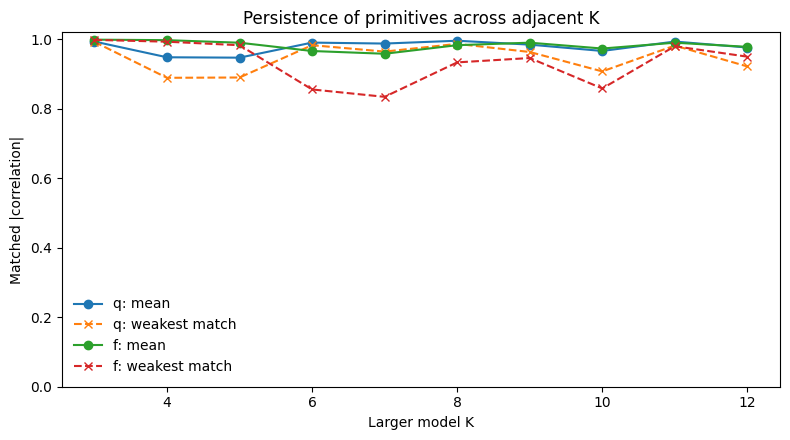

In [11]:
persistence_rows = []
for representation in ('q', 'f'):
    for k0, k1 in zip(AVAILABLE_K[:-1], AVAILABLE_K[1:]):
        p0 = primitive_time_domain(load_fada_fit(representation, k0), crop=False)
        p1 = primitive_time_domain(load_fada_fit(representation, k1), crop=False)
        rows, cols, scores, shifts, signs = align_primitives(
            p0, p1, max_shift=FADA_MAX_DELAY)
        for old_i, new_i, score, shift, sign in zip(rows, cols, scores, shifts, signs):
            persistence_rows.append({
                'representation': representation,
                'k_from': k0,
                'k_to': k1,
                'primitive_from': int(old_i) + 1,
                'primitive_to': int(new_i) + 1,
                'abs_correlation': float(score),
                'shift_samples': int(shift),
                'sign': float(sign),
            })

persistence = pd.DataFrame(persistence_rows)
display(persistence.head(20))
persistence.to_csv(ANALYSIS_OUTPUT / 'cross_k_matches.csv', index=False)

summary_persistence = (persistence
    .groupby(['representation', 'k_from', 'k_to'])['abs_correlation']
    .agg(['mean', 'median', 'min'])
    .reset_index())
display(summary_persistence)

fig, ax = plt.subplots(figsize=(8, 4.5))
for representation in ('q', 'f'):
    rows = summary_persistence[summary_persistence.representation == representation]
    ax.plot(rows.k_to, rows['mean'], marker='o', label=f'{representation}: mean')
    ax.plot(rows.k_to, rows['min'], marker='x', linestyle='--', label=f'{representation}: weakest match')
ax.set(xlabel='Larger model K', ylabel='Matched |correlation|', ylim=(0, 1.02),
       title='Persistence of primitives across adjacent K')
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(ANALYSIS_OUTPUT / 'cross_k_persistence.png', bbox_inches='tight')
plt.show()


## 12. Reconstruct held-out movements in physical joint space

### Why

NMSE compresses an entire trajectory into one number. A model can have a good average score while making systematic errors in specific joints or phases of movement. We therefore inspect several individual **test trials**.

The residual representation deserves one extra step. FADA fitted on `f` reconstructs only the endpoint-independent shape. To compare with the actual joint trajectory we restore the trial-specific endpoint baseline:

$$
\hat q_F(t)=h(t)+\hat f(t).
$$

This directly tests the representation we ultimately care about: **contextual start/end geometry plus a reusable movement-shape model**.

### How

For the same held-out trials we plot three trajectories for every joint:

- true `q`;
- FADA fitted directly to `q`;
- `h +` FADA fitted to `f`.

The trial examples are chosen reproducibly from the test set. They are examples, not a replacement for the aggregate NMSE analysis.


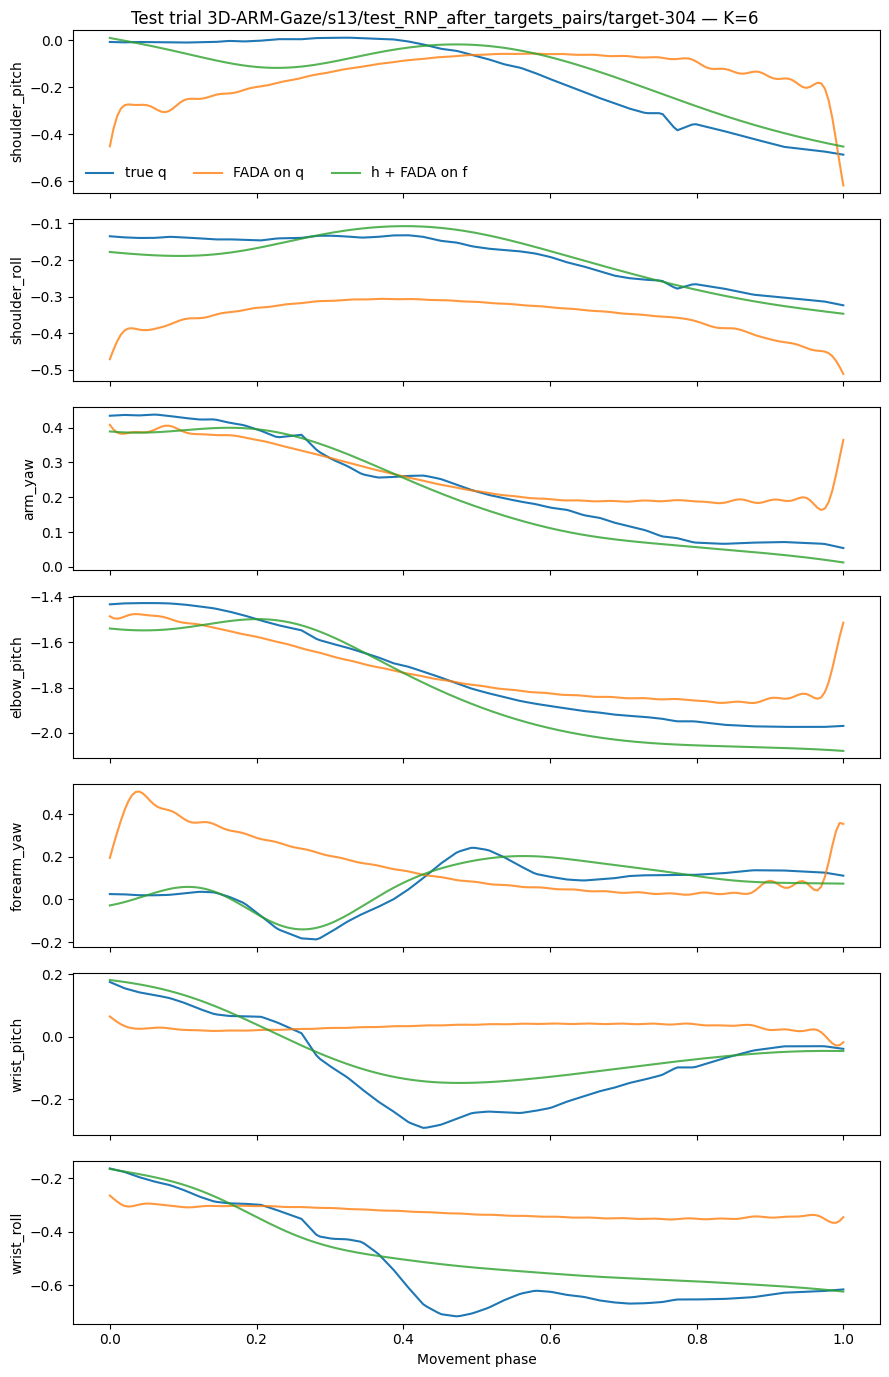

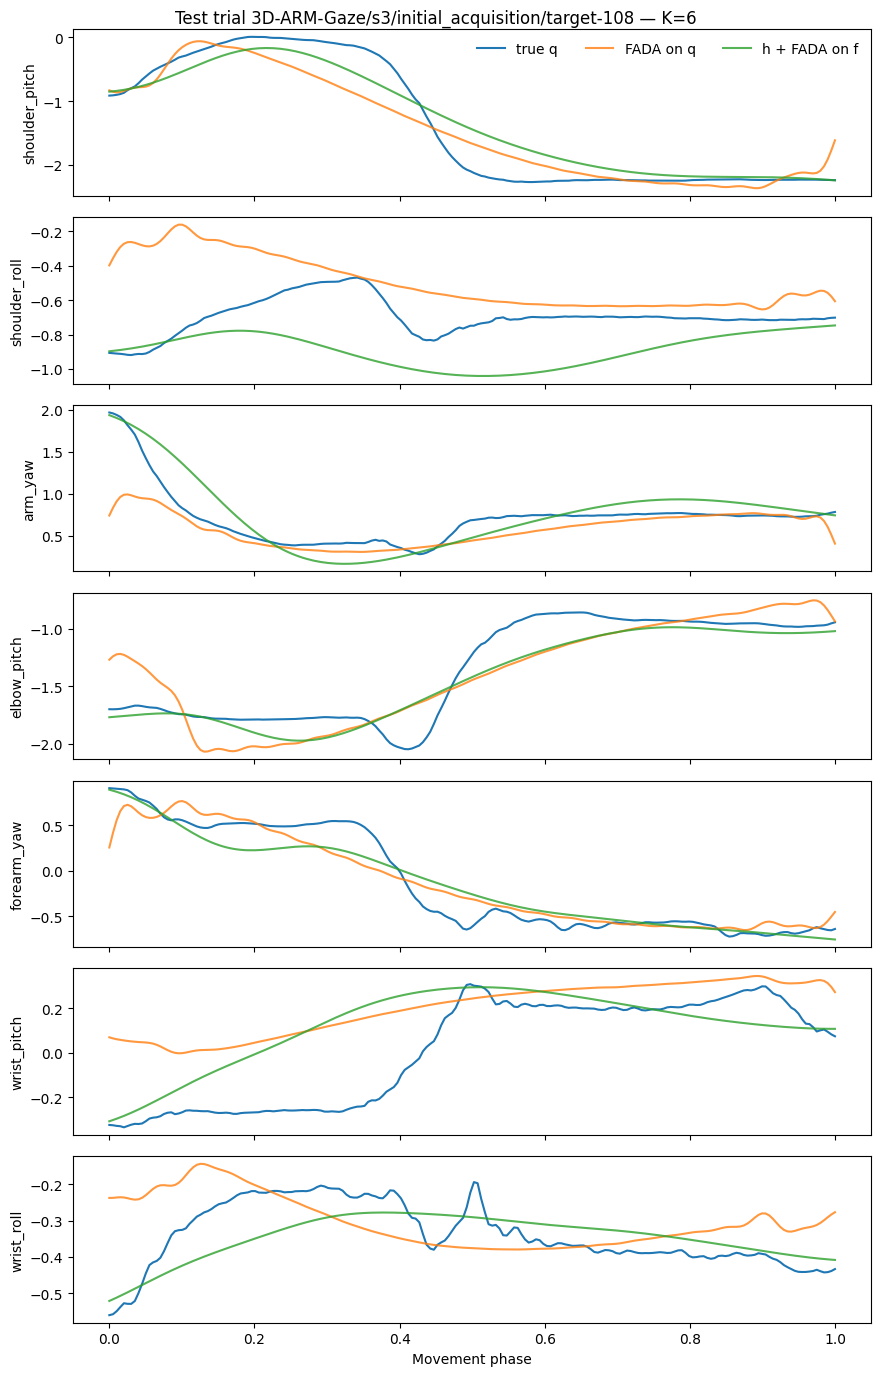

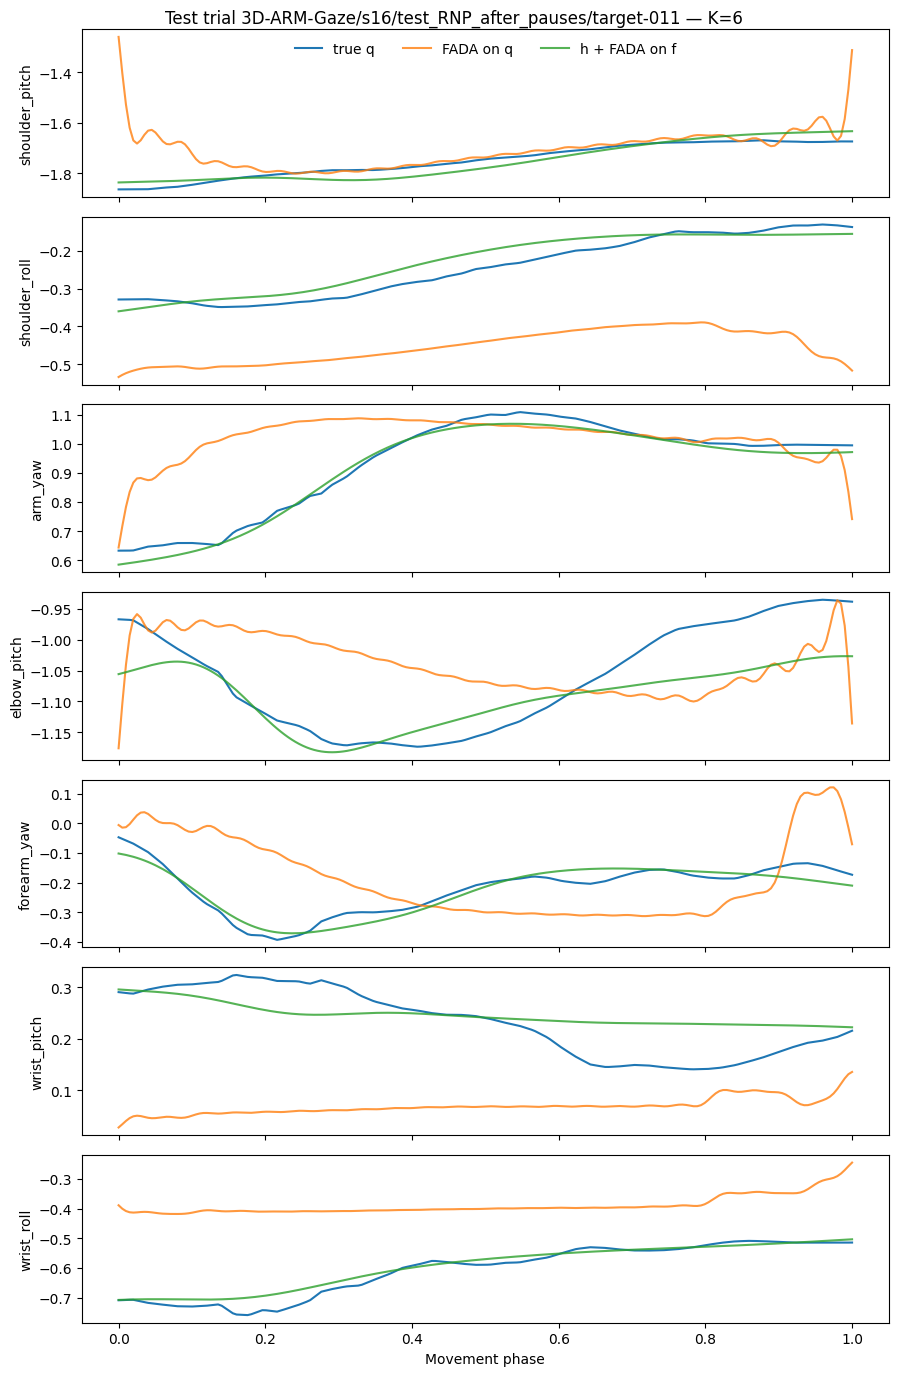

Test NMSE, direct q fit: 0.19926043890973974
Test NMSE, h + residual fit: 0.027478960988087435


In [12]:
q_reconstruction = reconstruct_saved_fit('q', INSPECT_K)
f_reconstruction = reconstruct_saved_fit('f', INSPECT_K)
q_from_f = H + f_reconstruction

test_indices = np.flatnonzero(split == 'test')
rng = np.random.default_rng(SEED)
chosen = rng.choice(test_indices, size=min(EXAMPLE_TRIALS, len(test_indices)), replace=False)
phase = np.linspace(0, 1, N_PHASE)

for trial_idx in chosen:
    fig, axes = plt.subplots(len(joints), 1, figsize=(9, 2.0 * len(joints)), sharex=True)
    for j, ax in enumerate(np.atleast_1d(axes)):
        ax.plot(phase, Q[trial_idx, :, j], label='true q')
        ax.plot(phase, q_reconstruction[trial_idx, :, j], label='FADA on q', alpha=0.8)
        ax.plot(phase, q_from_f[trial_idx, :, j], label='h + FADA on f', alpha=0.8)
        ax.set_ylabel(joints[j])
    axes[0].legend(frameon=False, ncol=3)
    axes[-1].set_xlabel('Movement phase')
    trial_id = metadata.loc[trial_idx, 'trial_id']
    fig.suptitle(f'Test trial {trial_id} — K={INSPECT_K}')
    fig.tight_layout()
    fig.savefig(ANALYSIS_OUTPUT / f'test_trial_{trial_idx}_k{INSPECT_K:02d}.png',
                bbox_inches='tight')
    plt.show()

print('Test NMSE, direct q fit:', nmse(Q[split == 'test'], q_reconstruction[split == 'test']))
print('Test NMSE, h + residual fit:', nmse(Q[split == 'test'], q_from_f[split == 'test']))


## 13. Compact FADA evidence table

### Why

The previous sections keep different ideas separate. This final table collects a few quantitative descriptors so that `K` can be discussed without reducing the decision to reconstruction error alone.

### Metrics

For each representation and K we report:

- test NMSE;
- improvement from the previous K;
- median **effective number of component contributions** for a trial;
- mean matched component-shape correlation from the previous K, when available.

The effective-contribution measure and the cross-K persistence measure are **our post-analysis diagnostics**; they are not quantities defined by FADA itself.

### How to use the table

The table is **not scored or ranked automatically**. It summarizes reconstruction quality, how distributed the fitted contributions are, and whether similar component shapes persist as K changes. The detailed plots remain necessary because averages can hide individual components.


In [13]:
rows = []
for representation in ('q', 'f'):
    rep_test = test_rows[test_rows.representation == representation].set_index('k')
    for k in AVAILABLE_K:
        _, _, effective_n = recruitment_for_fit(representation, k)
        previous_match = persistence[
            (persistence.representation == representation) &
            (persistence.k_to == k)
        ]
        rows.append({
            'representation': representation,
            'k': k,
            'test_nmse': float(rep_test.loc[k, 'nmse']),
            'nmse_gain_from_previous_k': rep_test.loc[k, 'nmse_gain_from_previous_k'],
            'median_effective_component_contributions': float(np.median(effective_n)),
            'mean_persistence_from_previous_k': (
                float(previous_match.abs_correlation.mean()) if len(previous_match) else np.nan),
        })

fada_evidence = pd.DataFrame(rows)
fada_evidence.to_csv(ANALYSIS_OUTPUT / 'fada_evidence_table.csv', index=False)
display(fada_evidence)


,representation,k,test_nmse,nmse_gain_from_previous_k,median_effective_component_contributions,mean_persistence_from_previous_k
0,q,2,0.457608,NaN,1.776506,NaN
1,q,3,0.362128,0.095480,2.398034,0.993495
2,q,4,0.299894,0.062234,3.044499,0.948200
3,q,5,0.247774,0.052120,3.598950,0.947097
4,q,6,0.199260,0.048514,4.207960,0.990467
5,q,7,0.150886,0.048374,4.826152,0.987687
6,q,8,0.109326,0.041561,5.458878,0.995858
7,q,9,0.084956,0.024370,5.984850,0.984589
8,q,10,0.070923,0.014033,6.382698,0.966401
9,q,11,0.055011,0.015912,6.838726,0.993480


## What this notebook can and cannot establish

The spatiotemporal FADA model already assumes a **trial-invariant library of primitive shapes** $w_p(t)$ and trial-specific coefficients/delays. Therefore this notebook cannot use the mere existence of a shared component shape as evidence that the component was empirically "reused"; that sharing is part of the model definition.

What we can test from the fitted results is whether a component is useful for our application by asking whether it is:

- part of a model with good held-out reconstruction;
- substantially recruited across many trials, subjects and conditions;
- associated with meaningful variation in trial-specific coefficient and/or timing;
- recognizable across nearby values of `K` in our cross-K robustness check;
- interpretable as a coherent multijoint temporal pattern.

None of those criteria alone proves that a component is a biological motor primitive. In particular:

- **low NMSE is not equivalent to primitive discovery**;
- broad recruitment concerns the trial-specific coefficients, not whether the shared shape "exists" across groups;
- the effective number of component contributions is our descriptive summary, not a FADA-defined primitive count;
- cross-K persistence is our robustness diagnostic, not the paper's fitting criterion.

This notebook analyses the current `random_trial` baseline. A harder held-out-subject or held-out-context fit would test a different question: whether the learned shared library and its recruitment generalize when whole subjects or movement contexts are absent during fitting.
\n\n### Additional empirical checks used here\n\nThe **context-breadth** and **leave-one-component-out reconstruction** analyses are our post-hoc diagnostics. They are not quantities defined by Chiovetto et al. They use FADA's fitted trial-specific coefficients to ask two questions relevant to this project: whether component recruitment spans different endpoint contexts, and how strongly the fitted reconstruction relies on each component.\n